<a href="https://colab.research.google.com/github/Pavithra1912006/data-science-ex-02/blob/main/DS_ex_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

df = pd.read_csv('/content/social_media_brand_analytics_100.csv')

df.head()

,Post_ID,Text,Timestamp,Platform,Engagement,Sentiment_Label
0,P096,love the affordable price,2026-01-01 12:15:00,Facebook,46,Neutral
1,P028,discount coupon did not work,2026-01-01 16:15:00,Facebook,38,Neutral
2,P062,price is too high,2026-01-02 17:00:00,TikTok,56,Negative
3,P003,the app is easy to use,2026-01-04 11:00:00,X,41,Positive
4,P082,discount coupon did not work,2026-01-05 11:45:00,X,68,Negative


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Rows: 100
Columns: 6

Column Names:
['Post_ID', 'Text', 'Timestamp', 'Platform', 'Engagement', 'Sentiment_Label']

Missing Values:
Post_ID            0
Text               0
Timestamp          0
Platform           0
Engagement         0
Sentiment_Label    0
dtype: int64

Duplicate Rows:
0

Data Types:
Post_ID            object
Text               object
Timestamp          object
Platform           object
Engagement          int64
Sentiment_Label    object
dtype: object


In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [7]:
df.isnull().sum()

,0
Post_ID,0
Text,0
Timestamp,0
Platform,0
Engagement,0
Sentiment_Label,0


In [8]:
df.isnull().sum()

,0
Post_ID,0
Text,0
Timestamp,0
Platform,0
Engagement,0
Sentiment_Label,0


In [9]:
df = df.drop_duplicates()

In [10]:
print(df['Sentiment_Label'].value_counts())

Sentiment_Label
Positive    41
Negative    35
Neutral     24
Name: count, dtype: int64


In [11]:
print(df['Platform'].value_counts())

Platform
Facebook     23
X            22
TikTok       21
Instagram    18
YouTube      16
Name: count, dtype: int64


In [12]:
print(df.describe())

                           Timestamp  Engagement
count                            100  100.000000
mean   2026-02-09 03:05:50.999999488   76.690000
min              2026-01-01 12:15:00   10.000000
25%              2026-01-18 05:26:15   49.000000
50%              2026-02-08 01:30:00   71.000000
75%              2026-02-26 00:00:00   95.000000
max              2026-03-28 15:15:00  181.000000
std                              NaN   36.308358


In [13]:
print("Average Engagement:", df['Engagement'].mean())
print("Median Engagement:", df['Engagement'].median())
print("Maximum Engagement:", df['Engagement'].max())
print("Minimum Engagement:", df['Engagement'].min())

Average Engagement: 76.69
Median Engagement: 71.0
Maximum Engagement: 181
Minimum Engagement: 10


In [14]:
sentiment_counts = df['Sentiment_Label'].value_counts()

print(sentiment_counts)

Sentiment_Label
Positive    41
Negative    35
Neutral     24
Name: count, dtype: int64


In [15]:
sentiment_counts = df['Sentiment_Label'].value_counts()

print(sentiment_counts)

Sentiment_Label
Positive    41
Negative    35
Neutral     24
Name: count, dtype: int64


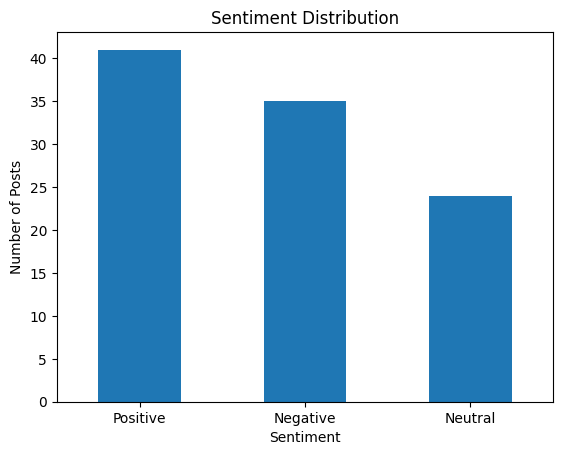

In [16]:
import matplotlib.pyplot as plt

df['Sentiment_Label'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

In [17]:
def identify_topic(text):
    text = text.lower()

    if any(word in text for word in ['delivery', 'delivered', 'arrived', 'package']):
        return 'Delivery'
    elif any(word in text for word in ['quality', 'product', 'working', 'damaged']):
        return 'Product Quality'
    elif any(word in text for word in ['price', 'affordable', 'cost']):
        return 'Price'
    elif any(word in text for word in ['support', 'customer care', 'customer service']):
        return 'Customer Service'
    elif any(word in text for word in ['app', 'website', 'login', 'checkout']):
        return 'App Experience'
    elif any(word in text for word in ['return', 'refund']):
        return 'Returns'
    elif any(word in text for word in ['offer', 'coupon', 'discount', 'sale']):
        return 'Offers'
    elif any(word in text for word in ['packaging', 'package', 'box']):
        return 'Packaging'
    else:
        return 'Other'

df['Topic'] = df['Text'].apply(identify_topic)

print(df[['Text', 'Topic']].head(15))

                                Text             Topic
0          love the affordable price             Price
1       discount coupon did not work            Offers
2                  price is too high             Price
3             the app is easy to use    App Experience
4       discount coupon did not work            Offers
5     delivery tracking is confusing          Delivery
6                 box arrived safely          Delivery
7          love the affordable price             Price
8                 app keeps crashing    App Experience
9   customer support solved my issue  Customer Service
10                  secure packaging         Packaging
11               fast delivery today          Delivery
12          helpful customer service  Customer Service
13             my order arrived late          Delivery
14        special offer is excellent            Offers


In [18]:
topic_counts = df['Topic'].value_counts()

print(topic_counts)

Topic
Delivery            25
Offers              19
Product Quality     18
Customer Service    12
App Experience      11
Price                9
Returns              4
Packaging            2
Name: count, dtype: int64


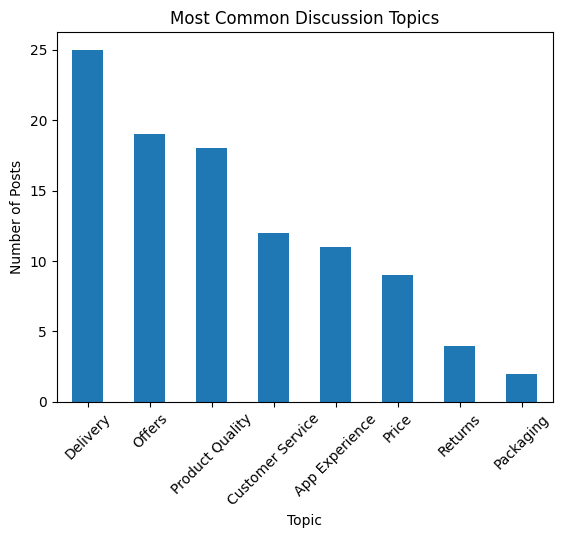

In [19]:
topic_counts.plot(kind='bar')

plt.title('Most Common Discussion Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.show()

In [20]:
topic_sentiment = pd.crosstab(
    df['Topic'],
    df['Sentiment_Label']
)

print(topic_sentiment)

Sentiment_Label   Negative  Neutral  Positive
Topic                                        
App Experience           5        1         5
Customer Service         4        2         6
Delivery                11        7         7
Offers                   3        6        10
Packaging                1        0         1
Price                    4        3         2
Product Quality          7        4         7
Returns                  0        1         3


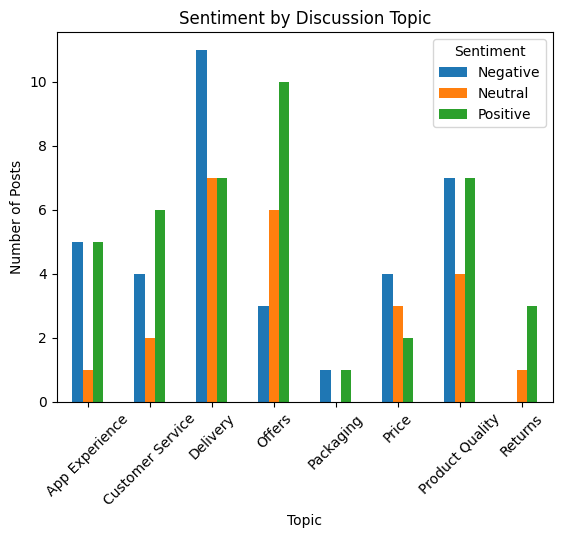

In [21]:
topic_sentiment.plot(kind='bar')

plt.title('Sentiment by Discussion Topic')
plt.xlabel('Topic')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()

In [22]:
topic_engagement = df.groupby('Topic')['Engagement'].mean()

print(topic_engagement.sort_values(ascending=False))

Topic
Returns             80.500000
Price               80.333333
Delivery            79.400000
Product Quality     78.277778
Offers              75.947368
App Experience      75.454545
Customer Service    70.000000
Packaging           58.500000
Name: Engagement, dtype: float64


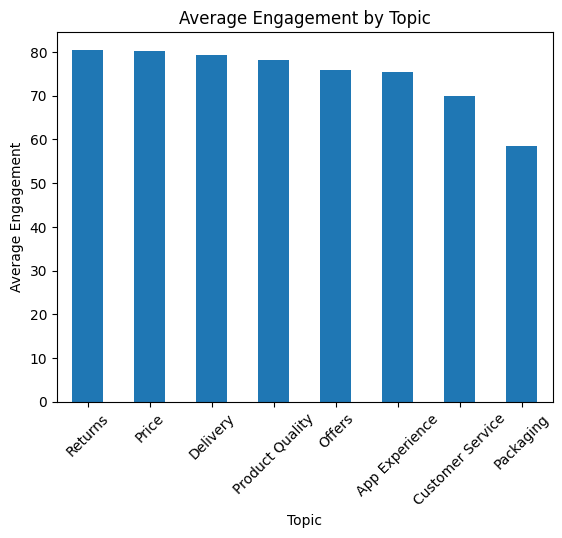

In [23]:
topic_engagement.sort_values(ascending=False).plot(kind='bar')

plt.title('Average Engagement by Topic')
plt.xlabel('Topic')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.show()

In [24]:
df['Date'] = df['Timestamp'].dt.date

In [25]:
delivery_trend = df[df['Topic'] == 'Delivery'].groupby('Date').size()

print(delivery_trend)

Date
2026-01-06    1
2026-01-09    1
2026-01-11    1
2026-01-14    1
2026-01-16    1
2026-01-25    1
2026-01-27    1
2026-02-01    1
2026-02-02    1
2026-02-03    1
2026-02-09    1
2026-02-10    1
2026-02-11    1
2026-02-12    2
2026-02-13    3
2026-02-15    1
2026-02-16    2
2026-02-22    1
2026-02-24    1
2026-02-28    1
2026-03-09    1
dtype: int64


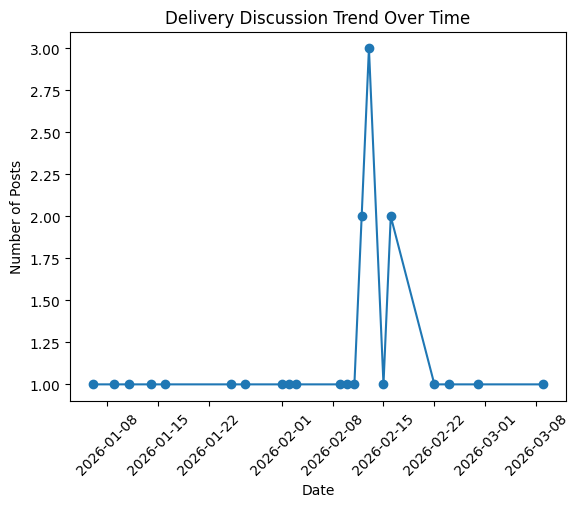

In [26]:
delivery_trend.plot(kind='line', marker='o')

plt.title('Delivery Discussion Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X = df['Text']
y = df['Sentiment_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [29]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [30]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

['Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Negative' 'Positive' 'Negative' 'Neutral' 'Neutral'
 'Negative' 'Positive' 'Negative' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive']


In [31]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(result)

      Actual Predicted
0   Positive  Positive
1   Positive  Positive
2   Positive  Positive
3   Positive  Positive
4    Neutral  Negative
5    Neutral  Negative
6   Negative  Negative
7   Negative  Negative
8   Positive  Positive
9   Negative  Negative
10  Negative   Neutral
11  Positive   Neutral
12   Neutral  Negative
13   Neutral  Positive
14  Negative  Negative
15  Negative  Positive
16  Negative  Negative
17   Neutral  Negative
18  Positive  Positive
19  Positive  Positive


In [32]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 60.0 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.71      0.62         7
     Neutral       0.00      0.00      0.00         5
    Positive       0.78      0.88      0.82         8

    accuracy                           0.60        20
   macro avg       0.44      0.53      0.48        20
weighted avg       0.51      0.60      0.55        20



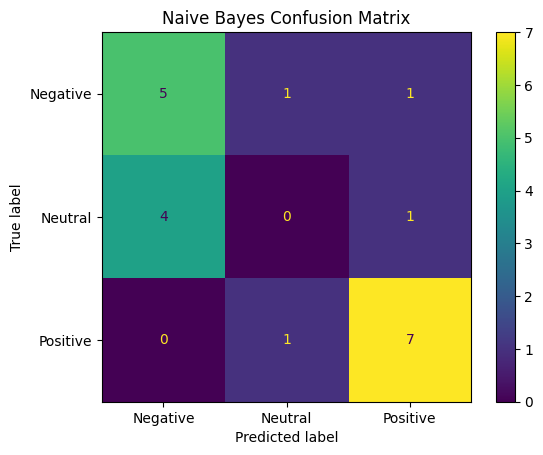

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [34]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment_Label'].value_counts()

print(sentiment_counts)

Sentiment_Label
Positive    41
Negative    35
Neutral     24
Name: count, dtype: int64


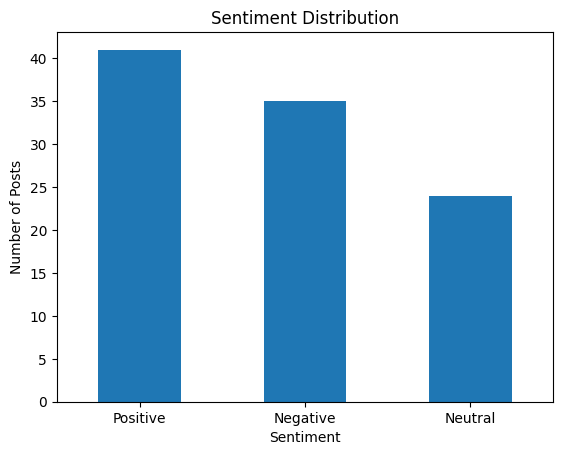

In [35]:
sentiment_counts.plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

In [36]:
sentiment_percentage = (
    df['Sentiment_Label']
    .value_counts(normalize=True) * 100
)

print(sentiment_percentage.round(2))

Sentiment_Label
Positive    41.0
Negative    35.0
Neutral     24.0
Name: proportion, dtype: float64


In [37]:
platform_counts = df['Platform'].value_counts()

print(platform_counts)

Platform
Facebook     23
X            22
TikTok       21
Instagram    18
YouTube      16
Name: count, dtype: int64


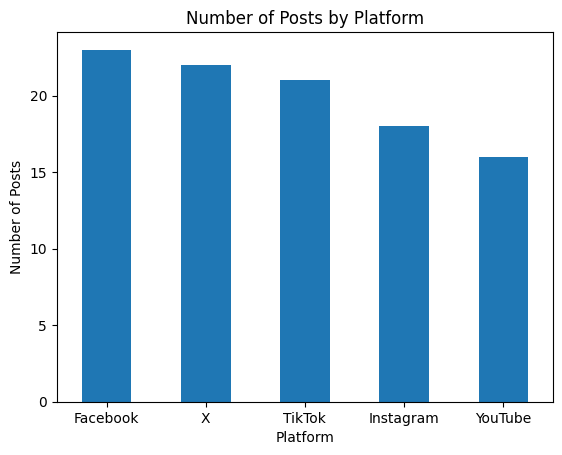

In [38]:
platform_counts.plot(kind='bar')

plt.title('Number of Posts by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

In [39]:
print("Average Engagement:", round(df['Engagement'].mean(), 2))
print("Median Engagement:", round(df['Engagement'].median(), 2))
print("Maximum Engagement:", df['Engagement'].max())
print("Minimum Engagement:", df['Engagement'].min())

Average Engagement: 76.69
Median Engagement: 71.0
Maximum Engagement: 181
Minimum Engagement: 10


In [40]:
print(
    df.groupby('Sentiment_Label')['Engagement']
      .mean()
      .round(2)
)

Sentiment_Label
Negative    96.77
Neutral     55.29
Positive    72.07
Name: Engagement, dtype: float64


In [41]:
def identify_topic(text):
    text = text.lower()

    if any(word in text for word in ['delivery', 'delivered', 'arrived', 'package']):
        return 'Delivery'

    elif any(word in text for word in ['quality', 'product', 'working', 'damaged']):
        return 'Product Quality'

    elif any(word in text for word in ['price', 'affordable', 'cost']):
        return 'Price'

    elif any(word in text for word in ['support', 'customer care', 'customer service']):
        return 'Customer Service'

    elif any(word in text for word in ['app', 'website', 'login', 'checkout']):
        return 'App Experience'

    elif any(word in text for word in ['return', 'refund']):
        return 'Returns'

    elif any(word in text for word in ['offer', 'coupon', 'discount', 'sale']):
        return 'Offers'

    elif any(word in text for word in ['packaging', 'package', 'box']):
        return 'Packaging'

    else:
        return 'Other'


df['Topic'] = df['Text'].apply(identify_topic)

print(df[['Post_ID', 'Text', 'Topic']].head(15))

   Post_ID                              Text             Topic
0     P096         love the affordable price             Price
1     P028      discount coupon did not work            Offers
2     P062                 price is too high             Price
3     P003            the app is easy to use    App Experience
4     P082      discount coupon did not work            Offers
5     P071    delivery tracking is confusing          Delivery
6     P064                box arrived safely          Delivery
7     P024         love the affordable price             Price
8     P057                app keeps crashing    App Experience
9     P040  customer support solved my issue  Customer Service
10    P059                  secure packaging         Packaging
11    P099               fast delivery today          Delivery
12    P012          helpful customer service  Customer Service
13    P002             my order arrived late          Delivery
14    P067        special offer is excellent           

In [42]:
print(df['Topic'].value_counts())

Topic
Delivery            25
Offers              19
Product Quality     18
Customer Service    12
App Experience      11
Price                9
Returns              4
Packaging            2
Name: count, dtype: int64


In [43]:
topic_counts = df['Topic'].value_counts()

print(topic_counts)

Topic
Delivery            25
Offers              19
Product Quality     18
Customer Service    12
App Experience      11
Price                9
Returns              4
Packaging            2
Name: count, dtype: int64


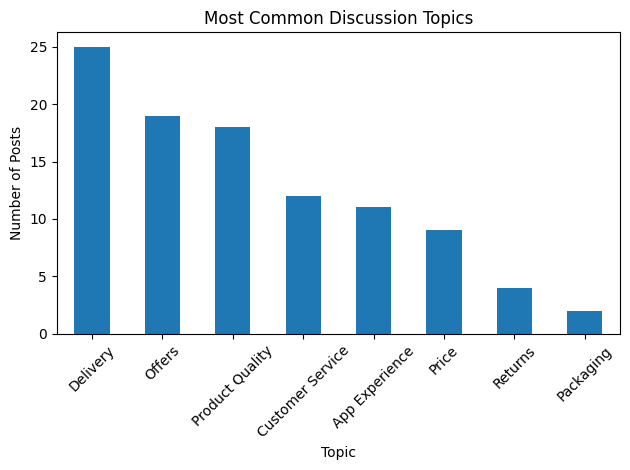

In [44]:
topic_counts.plot(kind='bar')

plt.title('Most Common Discussion Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
topic_engagement = (
    df.groupby('Topic')['Engagement']
      .mean()
      .sort_values(ascending=False)
)

print(topic_engagement.round(2))

Topic
Returns             80.50
Price               80.33
Delivery            79.40
Product Quality     78.28
Offers              75.95
App Experience      75.45
Customer Service    70.00
Packaging           58.50
Name: Engagement, dtype: float64


In [46]:
topic_total_engagement = (
    df.groupby('Topic')['Engagement']
      .sum()
      .sort_values(ascending=False)
)

print(topic_total_engagement)

Topic
Delivery            1985
Offers              1443
Product Quality     1409
Customer Service     840
App Experience       830
Price                723
Returns              322
Packaging            117
Name: Engagement, dtype: int64


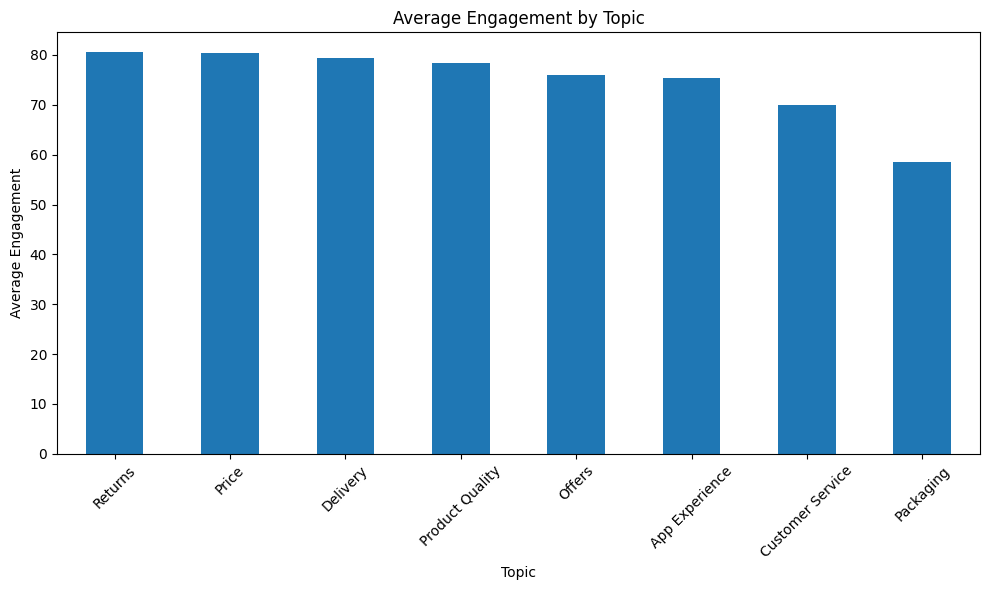

In [47]:
topic_engagement.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Engagement by Topic')
plt.xlabel('Topic')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
top_posts = df.sort_values(
    'Engagement',
    ascending=False
)[['Post_ID', 'Text', 'Topic', 'Sentiment_Label', 'Engagement']]

print(top_posts.head(10))

   Post_ID                       Text             Topic Sentiment_Label  \
70    P051      my order arrived late          Delivery        Negative   
13    P002      my order arrived late          Delivery        Negative   
31    P080          price is too high             Price        Negative   
53    P088   discount made it cheaper            Offers         Neutral   
25    P022      support never replied  Customer Service        Negative   
38    P077   quality is disappointing   Product Quality        Negative   
33    P011     delivery took too long          Delivery        Negative   
96    P066    product stopped working   Product Quality        Negative   
7     P024  love the affordable price             Price        Positive   
77    P016      support never replied  Customer Service        Negative   

    Engagement  
70         181  
13         173  
31         163  
53         157  
25         153  
38         139  
33         139  
96         138  
7          134  
77  

In [49]:
sentiment_engagement = (
    df.groupby('Sentiment_Label')['Engagement']
      .mean()
      .sort_values(ascending=False)
)

print(sentiment_engagement.round(2))

Sentiment_Label
Negative    96.77
Positive    72.07
Neutral     55.29
Name: Engagement, dtype: float64


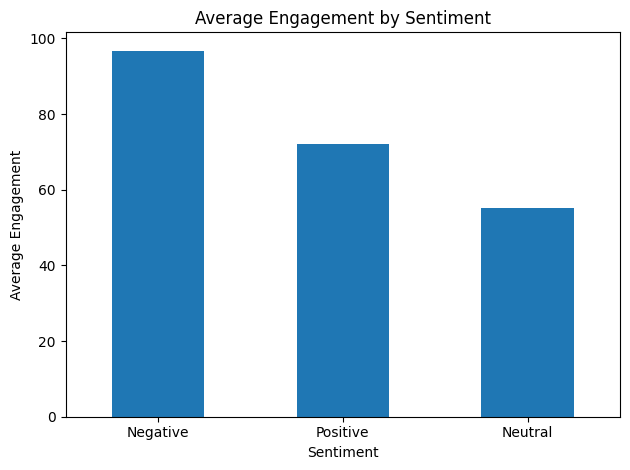

In [50]:
sentiment_engagement.plot(kind='bar')

plt.title('Average Engagement by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Engagement')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
df['Date'] = df['Timestamp'].dt.date

In [52]:
daily_posts = df.groupby('Date').size()

print(daily_posts)

Date
2026-01-01    2
2026-01-02    1
2026-01-04    1
2026-01-05    1
2026-01-06    1
2026-01-09    3
2026-01-10    1
2026-01-11    3
2026-01-14    4
2026-01-15    3
2026-01-16    2
2026-01-17    3
2026-01-18    1
2026-01-20    2
2026-01-21    1
2026-01-22    1
2026-01-23    2
2026-01-25    4
2026-01-26    1
2026-01-27    3
2026-01-31    1
2026-02-01    3
2026-02-02    1
2026-02-03    2
2026-02-05    2
2026-02-06    1
2026-02-09    3
2026-02-10    3
2026-02-11    1
2026-02-12    2
2026-02-13    5
2026-02-14    1
2026-02-15    1
2026-02-16    2
2026-02-17    1
2026-02-21    1
2026-02-22    2
2026-02-24    2
2026-02-25    1
2026-02-26    1
2026-02-28    1
2026-03-01    1
2026-03-04    1
2026-03-08    1
2026-03-09    2
2026-03-10    1
2026-03-12    3
2026-03-13    1
2026-03-15    2
2026-03-16    2
2026-03-17    2
2026-03-23    1
2026-03-25    4
2026-03-27    1
2026-03-28    1
dtype: int64


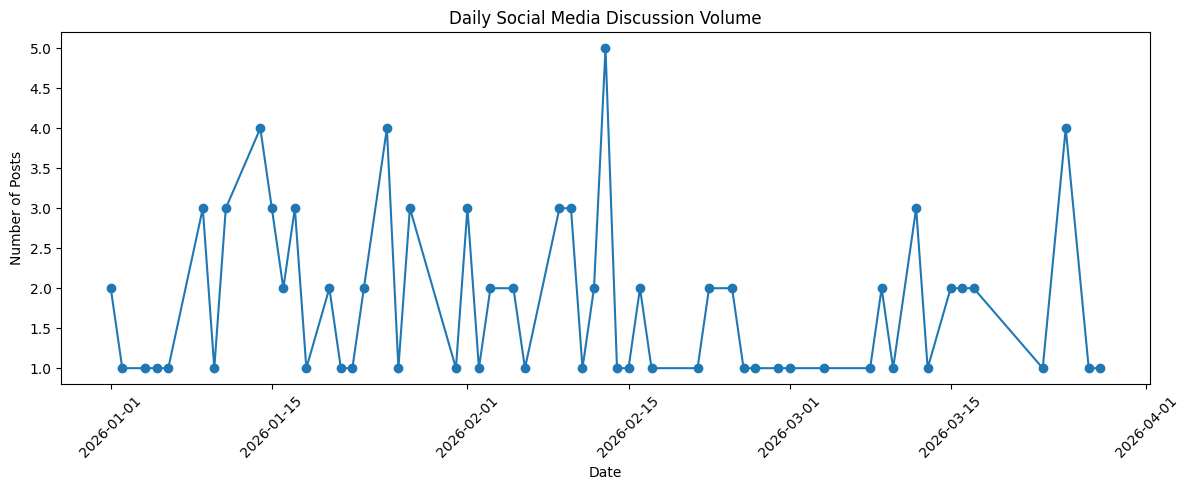

In [53]:
daily_posts.plot(
    kind='line',
    figsize=(12,5),
    marker='o'
)

plt.title('Daily Social Media Discussion Volume')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
delivery_df = df[df['Topic'] == 'Delivery']

delivery_daily = delivery_df.groupby('Date').size()

print(delivery_daily)

Date
2026-01-06    1
2026-01-09    1
2026-01-11    1
2026-01-14    1
2026-01-16    1
2026-01-25    1
2026-01-27    1
2026-02-01    1
2026-02-02    1
2026-02-03    1
2026-02-09    1
2026-02-10    1
2026-02-11    1
2026-02-12    2
2026-02-13    3
2026-02-15    1
2026-02-16    2
2026-02-22    1
2026-02-24    1
2026-02-28    1
2026-03-09    1
dtype: int64


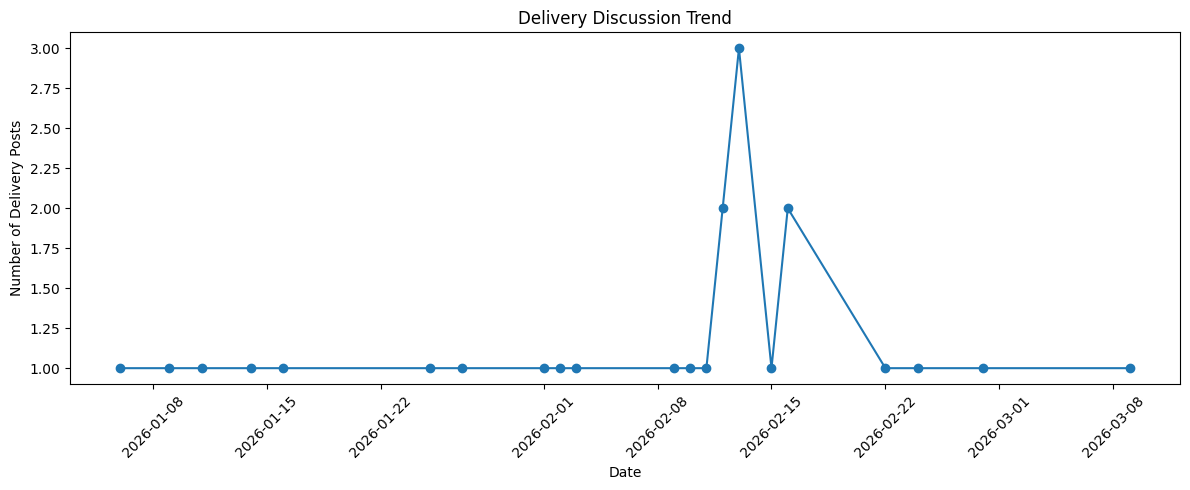

In [55]:
delivery_daily.plot(
    kind='line',
    figsize=(12,5),
    marker='o'
)

plt.title('Delivery Discussion Trend')
plt.xlabel('Date')
plt.ylabel('Number of Delivery Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
df.to_csv(
    '/content/social_media_brand_analytics_analyzed.csv',
    index=False
)

print("Analyzed dataset saved successfully.")

Analyzed dataset saved successfully.


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [58]:
X = df['Text']
y = df['Sentiment_Label']

print("Input:", X.name)
print("Target:", y.name)

Input: Text
Target: Sentiment_Label


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (80, 72)
Testing TF-IDF shape: (20, 72)


In [71]:
vectorizer.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 227 stored elements and shape (80, 72)>

In [72]:
vectorizer.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52 stored elements and shape (20, 72)>

In [73]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [74]:
y_pred = model.predict(X_test_tfidf)

print("Predicted Sentiments:")
print(y_pred)

Predicted Sentiments:
['Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Negative' 'Positive' 'Negative' 'Neutral' 'Neutral'
 'Negative' 'Positive' 'Negative' 'Positive' 'Negative' 'Negative'
 'Positive' 'Positive']


In [75]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results)

      Actual Predicted
0   Positive  Positive
1   Positive  Positive
2   Positive  Positive
3   Positive  Positive
4    Neutral  Negative
5    Neutral  Negative
6   Negative  Negative
7   Negative  Negative
8   Positive  Positive
9   Negative  Negative
10  Negative   Neutral
11  Positive   Neutral
12   Neutral  Negative
13   Neutral  Positive
14  Negative  Negative
15  Negative  Positive
16  Negative  Negative
17   Neutral  Negative
18  Positive  Positive
19  Positive  Positive


In [76]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Accuracy:", round(accuracy * 100, 2), "%")

Naive Bayes Accuracy: 60.0 %


In [77]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.71      0.62         7
     Neutral       0.00      0.00      0.00         5
    Positive       0.78      0.88      0.82         8

    accuracy                           0.60        20
   macro avg       0.44      0.53      0.48        20
weighted avg       0.51      0.60      0.55        20



In [78]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.71      0.62         7
     Neutral       0.00      0.00      0.00         5
    Positive       0.78      0.88      0.82         8

    accuracy                           0.60        20
   macro avg       0.44      0.53      0.48        20
weighted avg       0.51      0.60      0.55        20



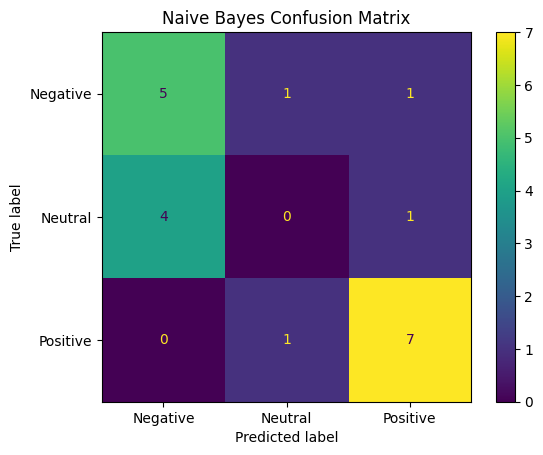

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [80]:
# FINAL ANALYSIS

print("===== DATASET SUMMARY =====")
print("Total Posts:", len(df))
print("Platforms:", df['Platform'].nunique())
print("Topics:", df['Topic'].nunique())

print("\n===== SENTIMENT =====")
print(df['Sentiment_Label'].value_counts())

print("\n===== TOPICS =====")
print(df['Topic'].value_counts())

print("\n===== AVERAGE ENGAGEMENT BY TOPIC =====")
print(
    df.groupby('Topic')['Engagement']
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

print("\n===== TOTAL ENGAGEMENT BY TOPIC =====")
print(
    df.groupby('Topic')['Engagement']
      .sum()
      .sort_values(ascending=False)
)

print("\n===== NEGATIVE POSTS BY TOPIC =====")
print(
    df[df['Sentiment_Label'] == 'Negative']['Topic']
      .value_counts()
)

print("\n===== ENGAGEMENT BY SENTIMENT =====")
print(
    df.groupby('Sentiment_Label')['Engagement']
      .mean()
      .round(2)
)

print("\n===== MODEL ACCURACY =====")
print(round(accuracy * 100, 2), "%")

===== DATASET SUMMARY =====
Total Posts: 100
Platforms: 5
Topics: 8

===== SENTIMENT =====
Sentiment_Label
Positive    41
Negative    35
Neutral     24
Name: count, dtype: int64

===== TOPICS =====
Topic
Delivery            25
Offers              19
Product Quality     18
Customer Service    12
App Experience      11
Price                9
Returns              4
Packaging            2
Name: count, dtype: int64

===== AVERAGE ENGAGEMENT BY TOPIC =====
Topic
Returns             80.50
Price               80.33
Delivery            79.40
Product Quality     78.28
Offers              75.95
App Experience      75.45
Customer Service    70.00
Packaging           58.50
Name: Engagement, dtype: float64

===== TOTAL ENGAGEMENT BY TOPIC =====
Topic
Delivery            1985
Offers              1443
Product Quality     1409
Customer Service     840
App Experience       830
Price                723
Returns              322
Packaging            117
Name: Engagement, dtype: int64

===== NEGATIVE POSTS 